In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import gc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd
from drd import DRD# stored in base

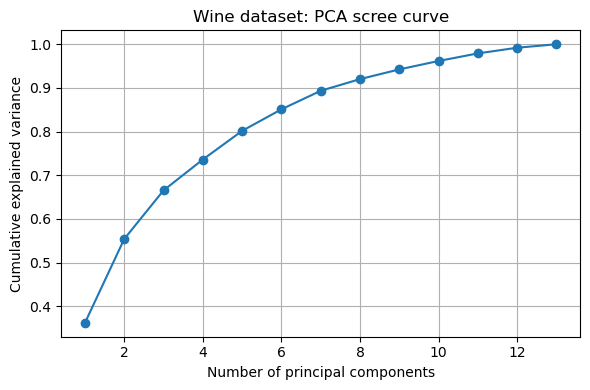

In [4]:
X = StandardScaler().fit_transform(load_wine().data)
pca = PCA().fit(X)
expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(expl_var)+1), cum_var, marker='o')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('Wine dataset: PCA scree curve')
plt.grid(True)
plt.tight_layout()

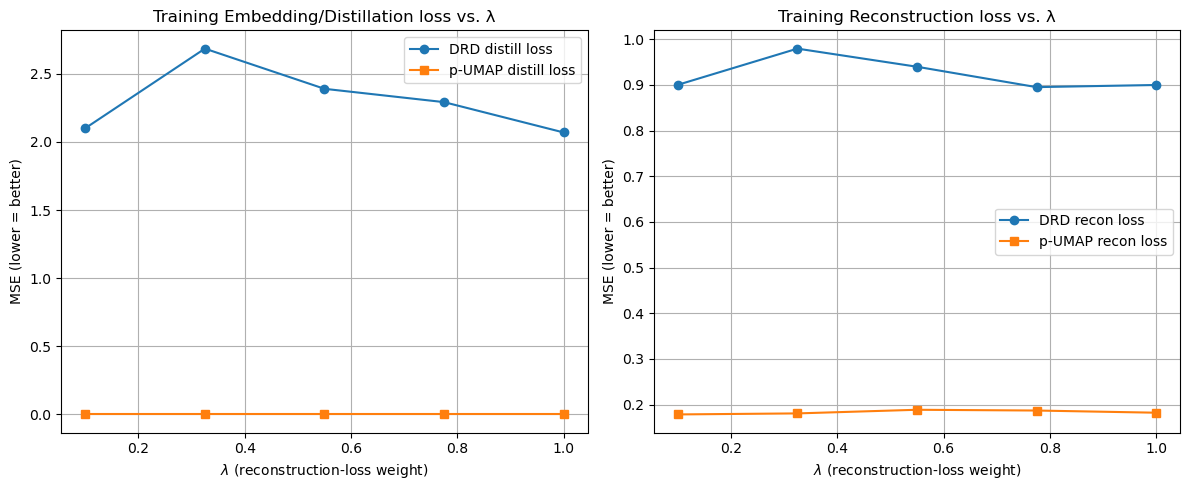

In [13]:
results = pd.read_csv('results/umap_drd_losses.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(results["lambda"], results["distill_drd_train"],  marker="o", label="DRD distill loss")
axes[0].plot(results["lambda"], results["distill_pumap_train"],marker="s", label="p-UMAP distill loss")
axes[0].set_xlabel(r"$\lambda$ (reconstruction-loss weight)")
axes[0].set_ylabel("MSE (lower = better)")
axes[0].set_title("Training Embedding/Distillation loss vs. λ")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(results["lambda"], results["recon_drd_train"],   marker="o", label="DRD recon loss")
axes[1].plot(results["lambda"], results["recon_pumap_train"], marker="s", label="p-UMAP recon loss")
axes[1].set_xlabel(r"$\lambda$ (reconstruction-loss weight)")
axes[1].set_ylabel("MSE (lower = better)")
axes[1].set_title("Training Reconstruction loss vs. λ")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

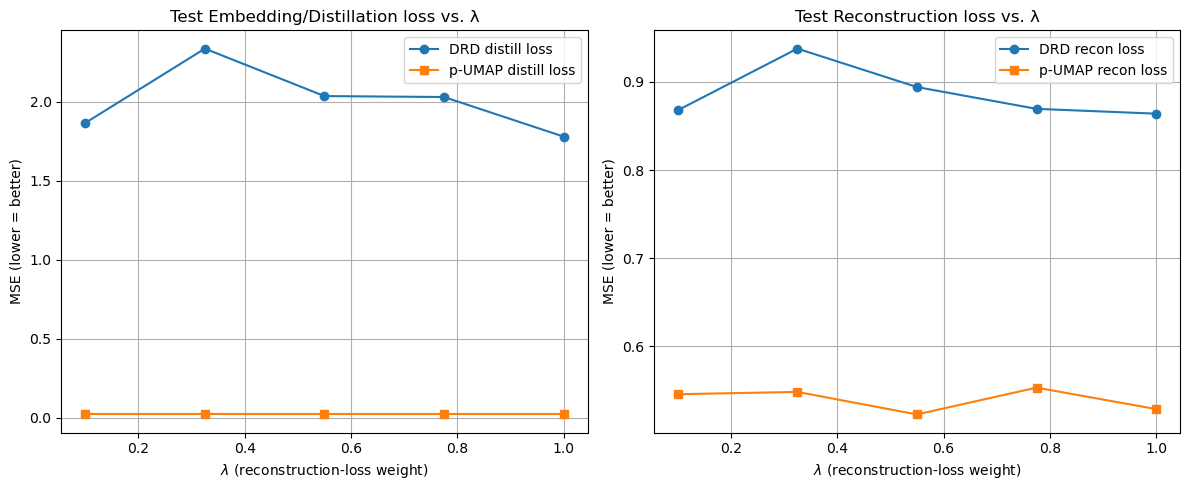

In [14]:
results = pd.read_csv('results/umap_drd_losses.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(results["lambda"], results["distill_drd_test"],  marker="o", label="DRD distill loss")
axes[0].plot(results["lambda"], results["distill_pumap_test"],marker="s", label="p-UMAP distill loss")
axes[0].set_xlabel(r"$\lambda$ (reconstruction-loss weight)")
axes[0].set_ylabel("MSE (lower = better)")
axes[0].set_title("Test Embedding/Distillation loss vs. λ")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(results["lambda"], results["recon_drd_test"],   marker="o", label="DRD recon loss")
axes[1].plot(results["lambda"], results["recon_pumap_test"], marker="s", label="p-UMAP recon loss")
axes[1].set_xlabel(r"$\lambda$ (reconstruction-loss weight)")
axes[1].set_ylabel("MSE (lower = better)")
axes[1].set_title("Test Reconstruction loss vs. λ")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
def load_datasets():
    wine_data = load_wine()
    X_wine = wine_data.data
    y_wine = wine_data.target

    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
    df_penguins = pd.read_csv(url).dropna()
    num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
    cat_features = ["island", "sex"]
    df_penguins = pd.get_dummies(df_penguins, columns=cat_features)
    X_penguins = df_penguins[num_features + list(df_penguins.columns[-3:])]
    y_penguins = LabelEncoder().fit_transform(df_penguins["species"])

    mnist = fetch_openml('mnist_784', version=1)
    X_mnist = mnist.data[:30000]
    y_mnist = LabelEncoder().fit_transform(mnist.target[:30000])

    return {
        "wine": (X_wine, y_wine),
        "penguins": (X_penguins, y_penguins),
        "MNIST": (X_mnist, y_mnist)
    }

def run_experiment(X, y,dataset_name, lambda_values):
    results = []
    if dataset_name == 'MNIST':
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(100/X.shape[0]), random_state=42)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(n_components=2)
    X_teacher_train = pca.fit_transform(X_train)
    X_teacher_test = pca.transform(X_test)
    embeddings = {"PCA": (X_teacher_test, y_test)}

    for lambda_d in lambda_values:
        gc.collect()
        torch.cuda.empty_cache()

        student_model_drd = DRD(input_dim=X.shape[1], latent_dim=2, epochs=50, batch_size=16 if X.shape[0] < 10000 else 128, lambda_d = lambda_d)  # Lowered batch size & epochs
        student_model_drd.fit(X_train, teacher_Z = X_teacher_train)

        


        embeddings[f"DRD, λ={lambda_d}"] = (student_model.transform(X_test), y_test)

        X_train_reconstructed = student_model.inverse_transform(student_model.transform(X_train))
        student_embedding_train = student_model.transform(X_train)
        train_recon_loss = np.mean((X_train - X_train_reconstructed) ** 2)
        train_teacher_student_loss = np.mean((X_teacher_train - student_embedding_train) ** 2)

        X_test_reconstructed = student_model.inverse_transform(student_model.transform(X_test))
        student_embedding_test = student_model.transform(X_test)
        test_recon_loss = np.mean((X_test - X_test_reconstructed) ** 2)
        test_teacher_student_loss = np.mean((X_teacher_test - student_embedding_test) ** 2)

        results.append({
            "lambda_d": lambda_d,
            "train_reconstruction_loss": train_recon_loss,
            "test_reconstruction_loss": test_recon_loss,
            "train_teacher_student_loss": train_teacher_student_loss,
            "test_teacher_student_loss": test_teacher_student_loss
        })

    return pd.DataFrame(results), embeddings

lambda_values=[np.linspace(0, 0.025, 5), np.linspace(0, 0.005, 5), np.linspace(0, 0.00001, 5)]
datasets = load_datasets()
experiment_results = {}
dataset_embeddings = {}

for i, (dataset_name, (X, y)) in enumerate(datasets.items()):
    print(f"Running experiments for {dataset_name}...")
    results, embs = run_experiment(X, y, dataset_name, lambda_values[i])
    experiment_results[dataset_name] = results
    dataset_embeddings[dataset_name] = embs


/apps/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Running experiments for wine...


100%|██████████| 50/50 [00:00<00:00, 50.96it/s]


Running experiments for penguins...


100%|██████████| 50/50 [00:01<00:00, 28.05it/s]


Running experiments for MNIST...


100%|██████████| 50/50 [00:47<00:00,  1.05it/s]


PCA
0.025
0.018750000000000003
0.0125
0.00625
0.0


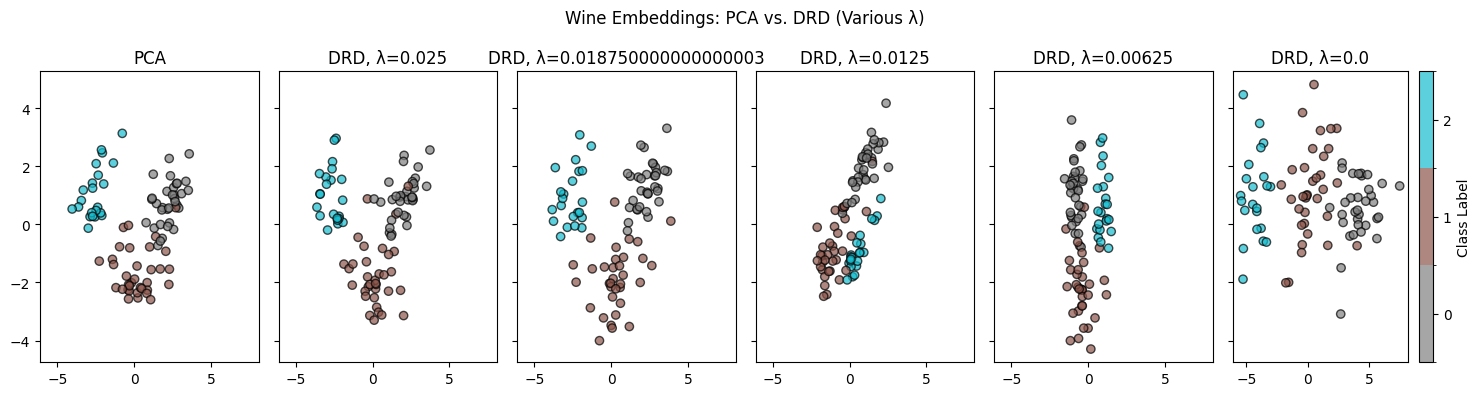

PCA
0.005
0.00375
0.0025
0.00125
0.0


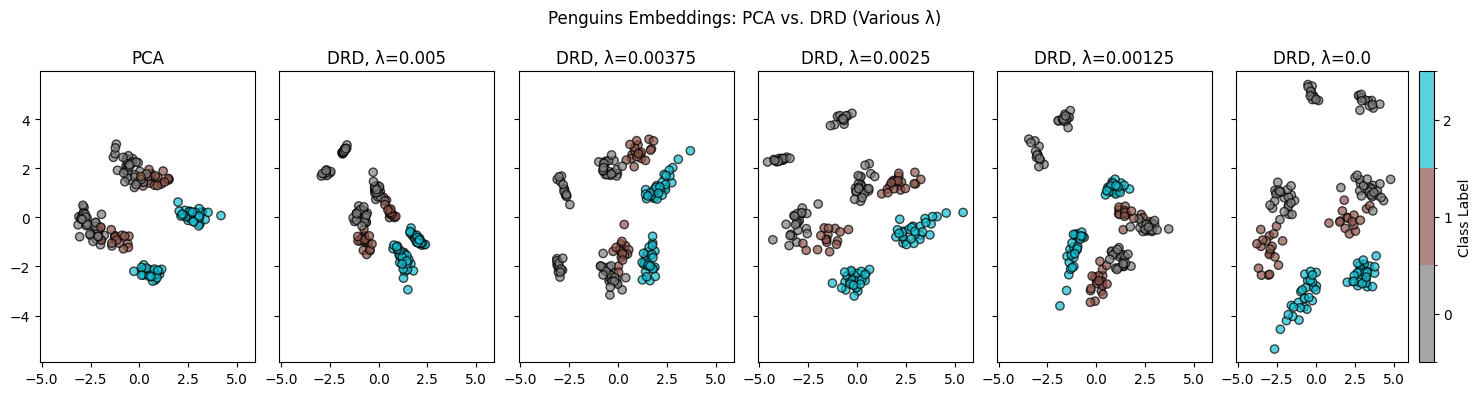

PCA
1e-05
7.500000000000001e-06
5e-06
2.5e-06
0.0


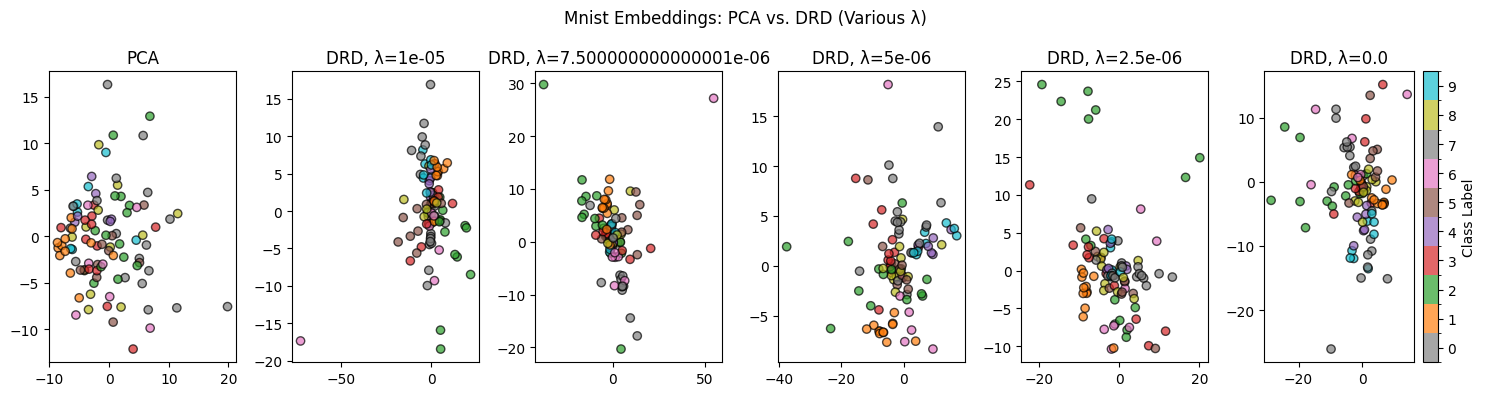

In [18]:

for i, (dataset_name, embeddings) in enumerate(dataset_embeddings.items()):
    y_embedded_sample = list(embeddings.values())[0][1]
    if isinstance(y_embedded_sample, pd.Series) and len(np.unique(y_embedded)) < 15:
        y_embedded_sample = y_embedded_sample.astype(str)
    label_encoder = LabelEncoder()
    y_embedded_sample = label_encoder.fit_transform(y_embedded_sample)
    num_classes = len(np.unique(y_embedded_sample))

    base_cmap = plt.colormaps["tab10"]  
    cmaplist = [base_cmap(i) for i in np.linspace(0, 1, num_classes)]
    cmaplist[0] = (0.5, 0.5, 0.5, 1.0)
    discrete_cmap = mpl.colors.ListedColormap(cmaplist)

    bounds = np.arange(num_classes + 1) - 0.5  
    norm = mpl.colors.BoundaryNorm(bounds, discrete_cmap.N)
    if dataset_name == 'MNIST':
        fig, axes = plt.subplots(1, len(lambda_values[i])+1, figsize=(15, 4), sharex=False, sharey=False)
    else:
        fig, axes = plt.subplots(1, len(lambda_values[i])+1, figsize=(15, 4), sharex=True, sharey=True)

    for i, key in enumerate(['PCA'] + list(lambda_values[i])[::-1]):
        print(key)
        if key != 'PCA':
            new_key = 'DRD, λ=' + str(key)
            X_embedded, y_embedded = embeddings[new_key]
        else:
            new_key = key
            X_embedded, y_embedded = embeddings[new_key]
        

        if isinstance(y_embedded, pd.Series) and len(np.unique(y_embedded)) < 15:
            y_embedded = y_embedded.astype(str)  

        y_embedded = label_encoder.transform(y_embedded) 

        scatter = axes[i].scatter(
            X_embedded[:, 0], X_embedded[:, 1], 
            c=y_embedded.astype(int),
            cmap=discrete_cmap, norm=norm, 
            alpha=0.7, edgecolor='k'
        )

        axes[i].set_title(new_key)

    cbar = fig.colorbar(scatter, ax=axes[-1], ticks=np.arange(num_classes))
    cbar.set_label("Class Label")
    cbar.set_ticks(np.arange(num_classes))  
    cbar.set_ticklabels(label_encoder.classes_ if 'label_encoder' in locals() else np.arange(num_classes))

    fig.suptitle(f"{dataset_name.capitalize()} Embeddings: PCA vs. DRD (Various λ)")
    plt.tight_layout()
    plt.show()
